# 01.5 — Label Quality & Leakage Groups

## Driver Drowsiness Detection 



1. **Near-duplicate leakage** — highly similar images must not be distributed across different train/validation/test splits.
2. **Cross-class near-duplicates** — visually similar images with different labels need visual review before training.




In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path("..").resolve()
DATASET_DIR = PROJECT_ROOT / "dataset" / "train"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METADATA_FILE = OUTPUT_DIR / "dataset_image_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET_DIR)
print("Metadata file:", METADATA_FILE)


Project root: D:\driver-drowsiness-detection
Dataset: D:\driver-drowsiness-detection\dataset\train
Metadata file: D:\driver-drowsiness-detection\outputs\dataset_image_metadata.csv


## 1. Load Dataset Metadata




In [2]:
if not METADATA_FILE.exists():
    raise FileNotFoundError(
        "dataset_image_metadata.csv was not found. "
        "Run 01_dataset_audit_exploration.ipynb first."
    )

meta_df = pd.read_csv(METADATA_FILE)

print("Images in metadata:", len(meta_df))
print("Classes:", sorted(meta_df["class"].unique()))

display(meta_df.head())


Images in metadata: 2900
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']


,path,filename,class,width,height,channels,mode,aspect_ratio,file_size_kb,valid,file_md5
0,D:\driver-drowsiness-detection\dataset\train\C...,_0.jpg,Closed,145,145,3,RGB,1.0000,6.09,True,f9319c997f4c75b111bd20bb6e22b1e1
1,D:\driver-drowsiness-detection\dataset\train\C...,_1.jpg,Closed,142,135,3,RGB,1.0519,10.14,True,5e42467e4a1e07235cc3a0cdf7d32f01
2,D:\driver-drowsiness-detection\dataset\train\C...,_10.jpg,Closed,131,127,3,RGB,1.0315,25.28,True,fbdbf633838b6268c8fc211258999021
3,D:\driver-drowsiness-detection\dataset\train\C...,_100.jpg,Closed,288,287,3,RGB,1.0035,17.08,True,435eaa857612d1ae5454501c221abd5d
4,D:\driver-drowsiness-detection\dataset\train\C...,_101.jpg,Closed,141,123,3,RGB,1.1463,26.18,True,9d0f18f02fc1990be2a0f9edb5376ff5


## 2. Recompute Near-Duplicate Pairs




In [3]:
def average_hash(path, hash_size=16):
    with Image.open(path) as img:
        img = img.convert("L").resize((hash_size, hash_size))
        arr = np.asarray(img, dtype=np.float32)
    return arr > arr.mean()

def hamming_distance(hash_a, hash_b):
    return int(np.count_nonzero(hash_a != hash_b))

hashes = {}

for path in meta_df["path"]:
    try:
        hashes[path] = average_hash(path)
    except Exception as exc:
        print("Hash failed:", path, exc)

paths = list(hashes.keys())

near_duplicate_pairs = []

for i in range(len(paths)):
    for j in range(i + 1, len(paths)):
        distance = hamming_distance(hashes[paths[i]], hashes[paths[j]])

        if distance <= 2:
            class_a = meta_df.loc[meta_df["path"] == paths[i], "class"].iloc[0]
            class_b = meta_df.loc[meta_df["path"] == paths[j], "class"].iloc[0]

            near_duplicate_pairs.append({
                "path_a": paths[i],
                "path_b": paths[j],
                "hash_distance": distance,
                "class_a": class_a,
                "class_b": class_b
            })

near_df = pd.DataFrame(near_duplicate_pairs)

print("Near-duplicate pairs:", len(near_df))
display(
    near_df.groupby(["class_a", "class_b"])
    .size()
    .reset_index(name="pair_count")
    .sort_values("pair_count", ascending=False)
)


Near-duplicate pairs: 702


,class_a,class_b,pair_count
1,no_yawn,no_yawn,364
3,yawn,yawn,331
2,no_yawn,yawn,6
0,Open,Open,1


## 3. Build Near-Duplicate Groups




In [4]:
# Union-Find / Disjoint Set implementation

parent = {path: path for path in meta_df["path"]}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    root_a = find(a)
    root_b = find(b)

    if root_a != root_b:
        parent[root_b] = root_a

for row in near_df.itertuples(index=False):
    union(row.path_a, row.path_b)

root_to_group = {}
group_ids = {}

next_group_id = 1

for path in meta_df["path"]:
    root = find(path)

    if root not in root_to_group:
        root_to_group[root] = f"SIM_{next_group_id:04d}"
        next_group_id += 1

    group_ids[path] = root_to_group[root]

manifest = meta_df.copy()
manifest["similarity_group_id"] = manifest["path"].map(group_ids)

print("Total similarity groups:", manifest["similarity_group_id"].nunique())
print("Total images:", len(manifest))


Total similarity groups: 2513
Total images: 2900


## 4. Inspect Similarity Group Sizes




In [5]:
group_sizes = (
    manifest.groupby("similarity_group_id")
    .agg(
        image_count=("path", "count"),
        class_count=("class", "nunique"),
        classes=("class", lambda x: ", ".join(sorted(set(x))))
    )
    .sort_values("image_count", ascending=False)
)

display(group_sizes.head(25))

print("Groups with more than one image:", int((group_sizes["image_count"] > 1).sum()))
print("Largest group size:", int(group_sizes["image_count"].max()))
print("Groups containing multiple classes:", int((group_sizes["class_count"] > 1).sum()))


,image_count,class_count,classes
similarity_group_id,,,
SIM_1973,17,1,yawn
SIM_1974,13,1,yawn
SIM_0983,12,2,"no_yawn, yawn"
SIM_1976,11,1,yawn
SIM_0731,10,1,no_yawn
SIM_0816,9,1,no_yawn
SIM_1118,9,1,no_yawn
SIM_1144,8,1,no_yawn
SIM_0868,8,1,no_yawn


Groups with more than one image: 169
Largest group size: 17
Groups containing multiple classes: 3


## 5. Identify Cross-Class Similarity Groups




In [6]:
cross_class_groups = (
    group_sizes[group_sizes["class_count"] > 1]
    .reset_index()
)

print("Cross-class similarity groups:", len(cross_class_groups))
display(cross_class_groups)


Cross-class similarity groups: 3


,similarity_group_id,image_count,class_count,classes
0,SIM_0983,12,2,"no_yawn, yawn"
1,SIM_0804,5,2,"no_yawn, yawn"
2,SIM_1225,2,2,"no_yawn, yawn"


## 6. Create Cross-Class Review Manifest



In [7]:
cross_group_ids = set(cross_class_groups["similarity_group_id"])

review_df = manifest[
    manifest["similarity_group_id"].isin(cross_group_ids)
].copy()

review_df = review_df.sort_values(
    ["similarity_group_id", "class", "filename"]
)

review_df["review_decision"] = ""
review_df["review_notes"] = ""

review_file = OUTPUT_DIR / "cross_class_review_manifest.csv"
review_df.to_csv(review_file, index=False)

print("Review images:", len(review_df))
print("Saved review manifest:", review_file)

display(
    review_df[
        ["similarity_group_id", "class", "filename", "path",
         "review_decision", "review_notes"]
    ]
)


Review images: 19
Saved review manifest: D:\driver-drowsiness-detection\outputs\cross_class_review_manifest.csv


,similarity_group_id,class,filename,path,review_decision,review_notes
833,SIM_0804,no_yawn,1411.jpg,D:\driver-drowsiness-detection\dataset\train\n...,,
834,SIM_0804,no_yawn,1412.jpg,D:\driver-drowsiness-detection\dataset\train\n...,,
835,SIM_0804,no_yawn,1413.jpg,D:\driver-drowsiness-detection\dataset\train\n...,,
2526,SIM_0804,yawn,413.jpg,D:\driver-drowsiness-detection\dataset\train\y...,,
2528,SIM_0804,yawn,415.jpg,D:\driver-drowsiness-detection\dataset\train\y...,,
1086,SIM_0983,no_yawn,223.jpg,D:\driver-drowsiness-detection\dataset\train\n...,,
1088,SIM_0983,no_yawn,224.jpg,D:\driver-drowsiness-detection\dataset\train\n...,,
1093,SIM_0983,no_yawn,225.jpg,D:\driver-drowsiness-detection\dataset\train\n...,,
1101,SIM_0983,no_yawn,226.jpg,D:\driver-drowsiness-detection\dataset\train\n...,,
1109,SIM_0983,no_yawn,229.jpg,D:\driver-drowsiness-detection\dataset\train\n...,,


## 7. Visualize Cross-Class Similarity Groups




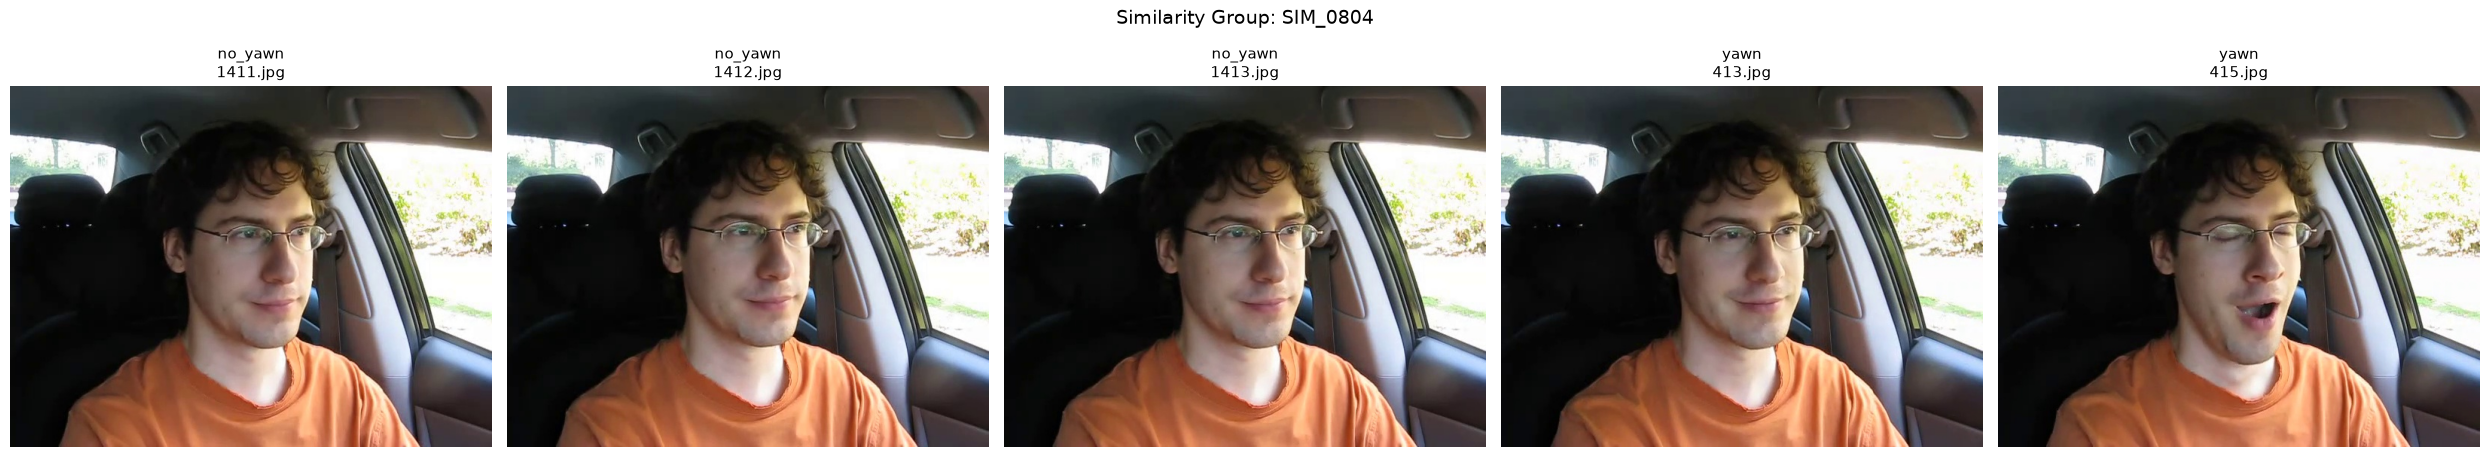

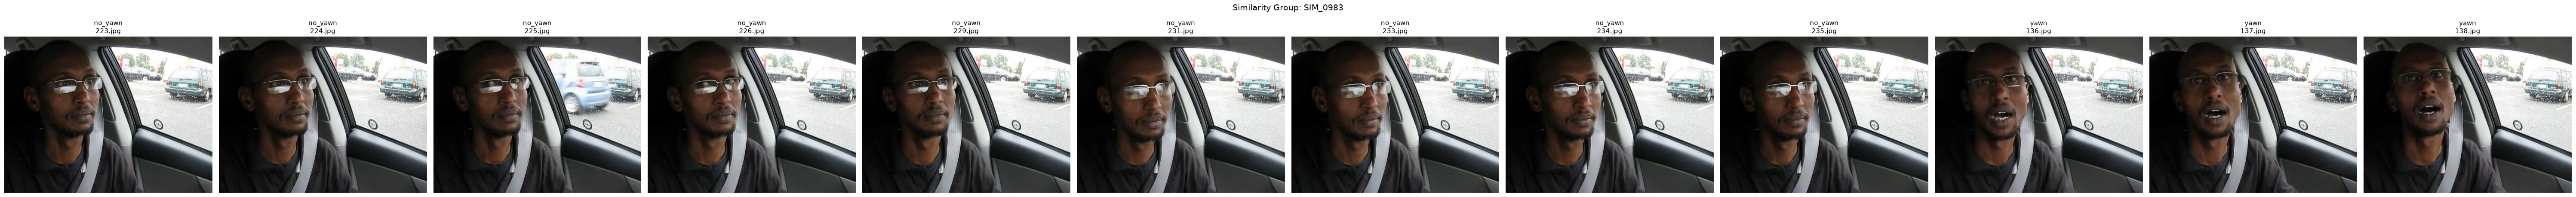

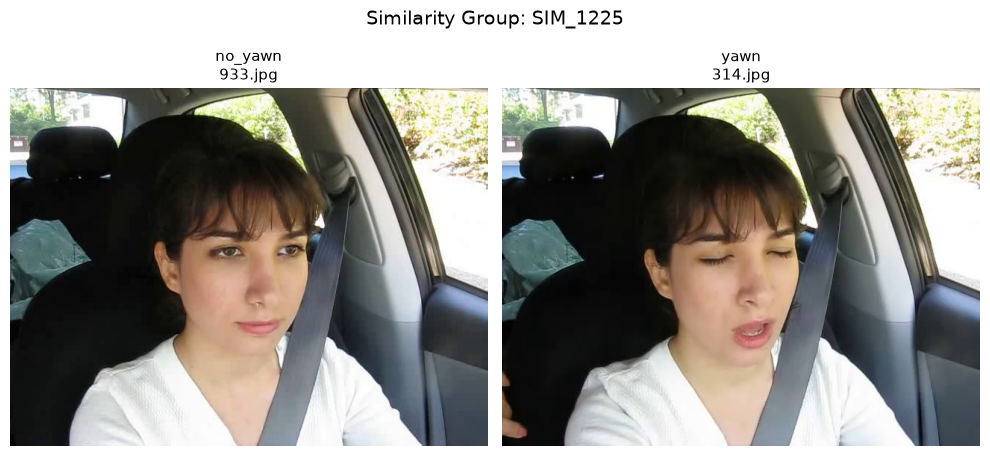

In [8]:
for group_id in sorted(cross_group_ids):
    group = review_df[review_df["similarity_group_id"] == group_id]

    n = len(group)
    fig, axes = plt.subplots(
        1, n,
        figsize=(5 * n, 5),
        squeeze=False
    )

    axes = axes[0]

    for ax, (_, row) in zip(axes, group.iterrows()):
        try:
            with Image.open(row["path"]) as img:
                ax.imshow(img.convert("RGB"))

            ax.set_title(
                f'{row["class"]}\n{row["filename"]}',
                fontsize=11
            )
            ax.axis("off")

        except Exception as exc:
            ax.text(0.5, 0.5, str(exc), ha="center", va="center")
            ax.axis("off")

    fig.suptitle(
        f"Similarity Group: {group_id}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()


## 8. Prepare a Leakage-Safe Manifest




In [9]:
manifest_file = OUTPUT_DIR / "dataset_manifest_with_similarity_groups.csv"

manifest.to_csv(manifest_file, index=False)

print("Saved:", manifest_file)

display(
    manifest[
        ["path", "class", "similarity_group_id"]
    ].head(20)
)


Saved: D:\driver-drowsiness-detection\outputs\dataset_manifest_with_similarity_groups.csv


,path,class,similarity_group_id
0,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0001
1,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0002
2,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0003
3,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0004
4,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0005
5,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0006
6,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0007
7,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0008
8,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0009
9,D:\driver-drowsiness-detection\dataset\train\C...,Closed,SIM_0010


## 9. Final Data





In [10]:
# Compact audit summary for the project log

summary = {
    "total_images": int(len(manifest)),
    "similarity_groups": int(manifest["similarity_group_id"].nunique()),
    "multi_image_groups": int((group_sizes["image_count"] > 1).sum()),
    "cross_class_groups": int(len(cross_class_groups)),
    "near_duplicate_pairs": int(len(near_df)),
    "cross_class_images_for_review": int(len(review_df))
}

print("DATA QUALITY SUMMARY")
for key, value in summary.items():
    print(f"{key}: {value}")

summary_file = OUTPUT_DIR / "data_quality_summary.json"

with open(summary_file, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:", summary_file)


DATA QUALITY SUMMARY
total_images: 2900
similarity_groups: 2513
multi_image_groups: 169
cross_class_groups: 3
near_duplicate_pairs: 702
cross_class_images_for_review: 19

Saved: D:\driver-drowsiness-detection\outputs\data_quality_summary.json
